In [30]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tf
import os 
import glob
from pathlib import Path
from tqdm.notebook import tqdm

In [2]:
def find_cilia_directories_pathlib(root_path, pattern="single cilia image*"):
    """
    Alternative implementation using pathlib (more modern approach).
    
    Args:
        root_path: Root directory to start searching from
        pattern: Glob pattern to match directory names
    
    Returns:
        Dictionary mapping directory paths to lists of files within them
    """
    cilia_dirs = {}
    root = Path(root_path)
    
    # Use rglob to recursively find matching directories
    for dir_path in root.rglob(pattern):
        if dir_path.is_dir():
            # Get only files (not subdirectories)
            files = [f.name for f in dir_path.iterdir() if f.is_file()]
            cilia_dirs[str(dir_path)] = files
    
    return cilia_dirs

In [3]:
cilia_dirs_m = find_cilia_directories_pathlib("/group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd1 cells_masks/")
cilia_dirs_i = find_cilia_directories_pathlib("/group/jug/aman/Cilia_Datasets/extracted/")

In [17]:
import pandas as pd
from pathlib import Path
import re

def paths_dict_to_dataframe(cilia_dirs_dict):
    """
    Convert the cilia directories dictionary to a structured DataFrame.
    
    Args:
        cilia_dirs_dict: Dictionary with directory paths as keys and file lists as values
    
    Returns:
        pandas DataFrame with extracted metadata
    """
    records = []
    
    for dir_path, files in cilia_dirs_dict.items():
        # Extract metadata from the path
        path_parts = Path(dir_path).parts
        
        # Extract condition (KO vs CTRL)
        condition = None
        for part in path_parts:
            if 'KO' in part:
                condition = 'KO'
                break
            elif 'CTRL' in part:
                condition = 'CTRL'
                break
        
        # Extract protein markers
        protein_markers = None
        for part in path_parts:
            if 'CCDC92' in part or 'ZDHHC5' in part:
                protein_markers = part
                break
        
        # Extract image number from directory name
        dir_name = Path(dir_path).name
        image_num_match = re.search(r'image(\d+)', dir_name)
        image_number = int(image_num_match.group(1)) if image_num_match else None
        
        # Create a record for each file
        for filename in files:
            # Skip system files
            if filename.startswith('.'):
                continue
                
            # Extract cilia number from filename
            cilia_match = re.search(r'_(\d+)-(\d+)cilia', filename)
            field_num = int(cilia_match.group(1)) if cilia_match else None
            cilia_num = int(cilia_match.group(2)) if cilia_match else None
            
            # Check file extension
            file_ext = Path(filename).suffix
            
            # Create key by splitting filename at 'cilia'
            key = filename.split('cilia')[0] if 'cilia' in filename else filename
            
            record = {
                'directory_path': dir_path,
                'directory_name': dir_name,
                'filename': filename,
                'full_path': str(Path(dir_path) / filename),
                'key': key,
                'condition': condition,
                'protein_markers': protein_markers,
                'image_number': image_number,
                'field_number': field_num,
                'cilia_number': cilia_num,
                'file_extension': file_ext
            }
            
            records.append(record)
    
    df = pd.DataFrame(records)
    
    # Sort for better organization
    df = df.sort_values(['condition', 'protein_markers', 'image_number', 
                         'field_number', 'cilia_number']).reset_index(drop=True)
    
    return df


def get_summary_stats(df):
    """
    Generate summary statistics from the cilia DataFrame.
    """
    print("=" * 60)
    print("DATASET SUMMARY")
    print("=" * 60)
    
    print(f"\nTotal files: {len(df)}")
    print(f"Total directories: {df['directory_path'].nunique()}")
    
    print("\n--- By Condition ---")
    print(df['condition'].value_counts())
    
    print("\n--- By Protein Markers ---")
    print(df['protein_markers'].value_counts())
    
    print("\n--- Files per Image Number ---")
    print(df.groupby(['condition', 'protein_markers', 'image_number']).size())
    
    print("\n--- File Extensions ---")
    print(df['file_extension'].value_counts())
    
    return df.describe(include='all')

    
    # Save to CSV (optional)
    # df.to_csv('cilia_dataset_index.csv', index=False)
    # print("\nDataFrame saved to 'cilia_dataset_index.csv'")

In [18]:
# Convert to DataFrame
df_images = paths_dict_to_dataframe(cilia_dirs_i)

print("DataFrame shape:", df_images.shape)
print("\nFirst few rows:")
print(df_images.head(10))

print("\nColumn names:")
print(df_images.columns.tolist())

# Get summary statistics
summary = get_summary_stats(df_images)

# Example: Filter for specific conditions
print("\n" + "=" * 60)
print("EXAMPLE FILTERING")
print("=" * 60)

# Get only KO samples
ko_samples = df_images[df_images['condition'] == 'KO']
print(f"\nKO samples: {len(ko_samples)}")

# Get specific protein marker
ccdc92_samples = df_images[df_images['protein_markers'].str.contains('CCDC92', na=False)]
print(f"CCDC92 samples: {len(ccdc92_samples)}")

# Get specific image number
image01_samples = df_images[df_images['image_number'] == 1]
print(f"Image 01 samples: {len(image01_samples)}")

DataFrame shape: (640, 11)

First few rows:
                                      directory_path        directory_name  \
0  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image01   
1  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image01   
2  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image01   
3  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image01   
4  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image01   
5  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image01   
6  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image01   
7  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image02   
8  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image02   
9  /group/jug/aman/Cilia_Datasets/extracted/W19 -...  single cilia image02   

                                            filename  \
0  IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TU

In [19]:
# Convert to DataFrame
df_masks = paths_dict_to_dataframe(cilia_dirs_m)

print("DataFrame shape:", df_masks.shape)
print("\nFirst few rows:")
print(df_masks.head(10))

print("\nColumn names:")
print(df_masks.columns.tolist())

# Get summary statistics
summary = get_summary_stats(df_masks)

# Example: Filter for specific conditions
print("\n" + "=" * 60)
print("EXAMPLE FILTERING")
print("=" * 60)

# Get only KO samples
ko_samples = df_masks[df_masks['condition'] == 'KO']
print(f"\nKO samples: {len(ko_samples)}")

# Get specific protein marker
ccdc92_samples = df_masks[df_masks['protein_markers'].str.contains('CCDC92', na=False)]
print(f"CCDC92 samples: {len(ccdc92_samples)}")

# Get specific image number
image01_samples = df_masks[df_masks['image_number'] == 1]
print(f"Image 01 samples: {len(image01_samples)}")

DataFrame shape: (291, 11)

First few rows:
                                      directory_path        directory_name  \
0  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image01   
1  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image01   
2  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image01   
3  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image01   
4  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image01   
5  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image01   
6  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image01   
7  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image02   
8  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image02   
9  /group/jug/aman/Cilia_Datasets/W19 - 2025_Pkhd...  single cilia image02   

                                            filename  \
0  IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TU

In [22]:
df_masks['key'], df_images['key']

(0      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-1
 1      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-2
 2      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-3
 3      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-4
 4      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-5
                              ...                        
 286     IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_9-22
 287     IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_9-23
 288     IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_9-24
 289     IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_9-25
 290     IMCD3 Pkhd KO - Zdhhc5, ARL13B, Y-TUB, DAPI_9-26
 Name: key, Length: 291, dtype: object,
 0      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-1
 1      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-2
 2      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-3
 3      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-4
 4      IMCD3 Pkhd CTRL - CCDC92, ARL13B, Y-TUB, DAPI_1-5
                              ..

In [23]:
common_keys = set(df_masks['key']) & set(df_images['key'])


In [27]:
masks_paths = df_masks[df_masks['key'].isin(common_keys)]['full_path']
images_paths = df_images[df_images['key'].isin(common_keys)]['full_path']

In [32]:
masks = []
images = []
for mp, ip in tqdm(zip(sorted(masks_paths), sorted(images_paths))):
    try:
        masks.append(tf.imread(mp))
    except Exception as e:
        print(f"Error reading mask {mp}: {e}")
    try:
        images.append(tf.imread(ip))
    except Exception as e:
        print(f"Error reading image {ip}: {e}")

0it [00:00, ?it/s]

Error reading image /group/jug/aman/Cilia_Datasets/extracted/W19 - 2025_Pkhd1_cells/W19 - 2025_Pkhd1 cells/CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image07/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_7-10cilia_CQP.txt: not a TIFF file b'Star'
Error reading image /group/jug/aman/Cilia_Datasets/extracted/W19 - 2025_Pkhd1_cells/W19 - 2025_Pkhd1 cells/CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image07/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_7-10cilia_CQP_ed.txt: not a TIFF file b'Savi'
Error reading image /group/jug/aman/Cilia_Datasets/extracted/W19 - 2025_Pkhd1_cells/W19 - 2025_Pkhd1 cells/CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image/single cilia image07/IMCD3 Pkhd KO - CCDC92, ARL13B, Y-TUB, DAPI_7-10cilia_CQP_ed_CQ.txt: not a TIFF file b'Savi'
Error reading image /group/jug/aman/Cilia_Datasets/extracted/W19 - 2025_Pkhd1_cells/W19 - 2025_Pkhd1 cells/CCDC92, Y-tub, Arl13b, DAPI/Pkhd1 KO/Cropped original image

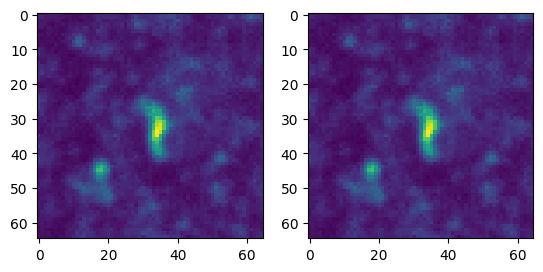

In [50]:
plt.subplot(121)
plt.imshow(images[0][7,-1])
plt.subplot(122)
plt.imshow(masks[0][7,5])

In [57]:
z_slices = [masks[i].shape[0] for i in range(len(masks))]

In [69]:
images = np.concatenate(masks, axis=0)[:,[3,5]]
masks = np.concatenate(masks, axis=0)[:,[2,4]]


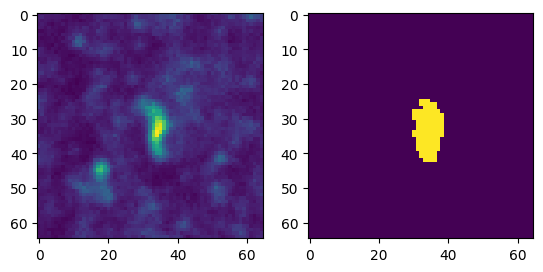

In [71]:
plt.subplot(121)
plt.imshow(images[7, 1])
plt.subplot(122)
plt.imshow(masks[7, 1])

In [72]:
tf.imwrite('/home/aman.kukde/cilia_ai/data/images.tif', images)
tf.imwrite('/home/aman.kukde/cilia_ai/data/masks.tif', masks)
tf.imwrite('/home/aman.kukde/cilia_ai/data/z_stacks_record.tif',z_slices)